Loaded 7881 samples from /home/ahsan/test-project/ISIC-2019/ISIC_Metadata/train_metadata_without_patches_size_shortcut.csv
  Benign    (class 1): 6310
  Malignant (class 2): 1571
Loaded 398 samples from /home/ahsan/test-project/fss/ISIC/ISIC_metadata/test_metadata_sample_data.csv
  Benign    (class 1): 199
  Malignant (class 2): 199



[Train] Unique class values in masks: [0, 1, 2]
  OK — all 3 classes present (0=bg, 1=benign, 2=malignant)

[Test] Unique class values in masks: [0, 1, 2]
  OK — all 3 classes present (0=bg, 1=benign, 2=malignant)

Training seed 22
Epoch 1/60:
  Train Loss:0.3942  Dice:0.6043  Acc:0.8745  IoU:0.4532
  Val   Loss:0.1841  Dice:0.6113  Acc:0.8611  IoU:0.4567
Epoch 10/60:
  Train Loss:0.1921  Dice:0.7293  Acc:0.9280  IoU:0.5873
  Val   Loss:0.2013  Dice:0.4883  Acc:0.8566  IoU:0.3693
Epoch 20/60:
  Train Loss:0.1567  Dice:0.7797  Acc:0.9387  IoU:0.6487
  Val   Loss:0.1870  Dice:0.5291  Acc:0.8794  IoU:0.4071
Epoch 30/60:
  Train Loss:0.1472  Dice:0.7933  Acc:0.9425  IoU:0.6683
  Val   Loss:0.1800  Dice:0.5473  Acc:0.8851  IoU:0.4279
Epoch 40/60:
  Train Loss:0.1363  Dice:0.8091  Acc:0.9462  IoU:0.6889
  Val   Loss:0.1614  Dice:0.6009  Acc:0.8927  IoU:0.4673
Epoch 50/60:
  Train Loss:0.1284  Dice:0.8208  Acc:0.9474  IoU:0.7028
  Val   Loss:0.1647  Dice:0.5905  Acc:0.8936  IoU:0.4590
Epoch 

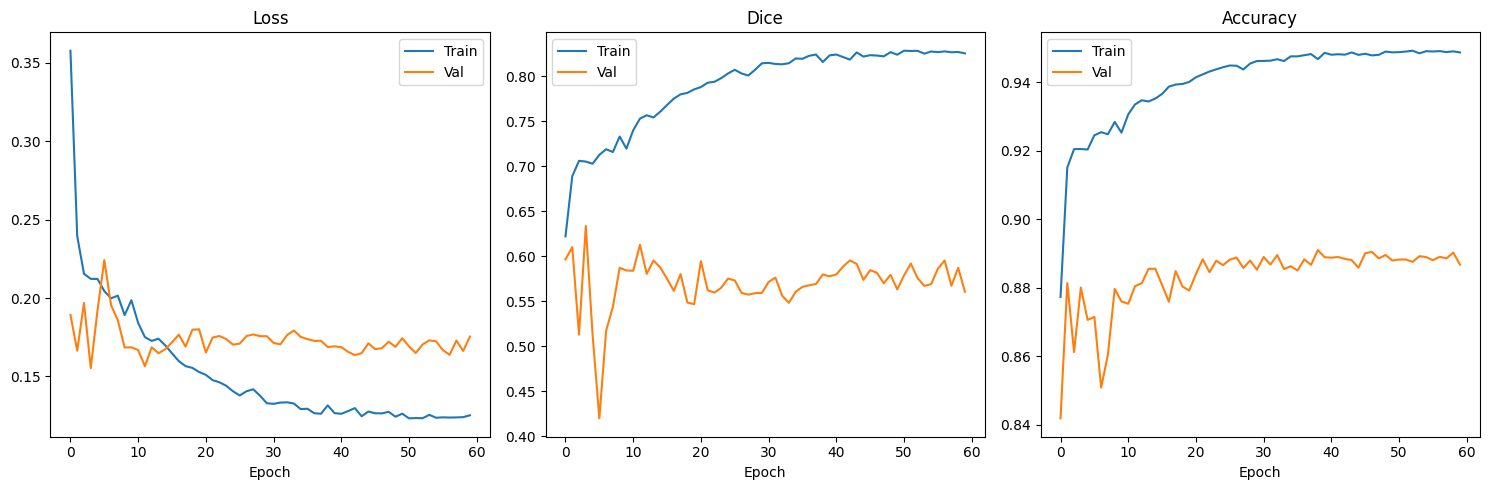

Sample 1: GT=benign  Pred=benign
Sample 2: GT=benign  Pred=benign
Sample 3: GT=benign  Pred=malignant
Sample 4: GT=benign  Pred=benign
Sample 5: GT=benign  Pred=malignant
Avg Test Dice: 0.0941


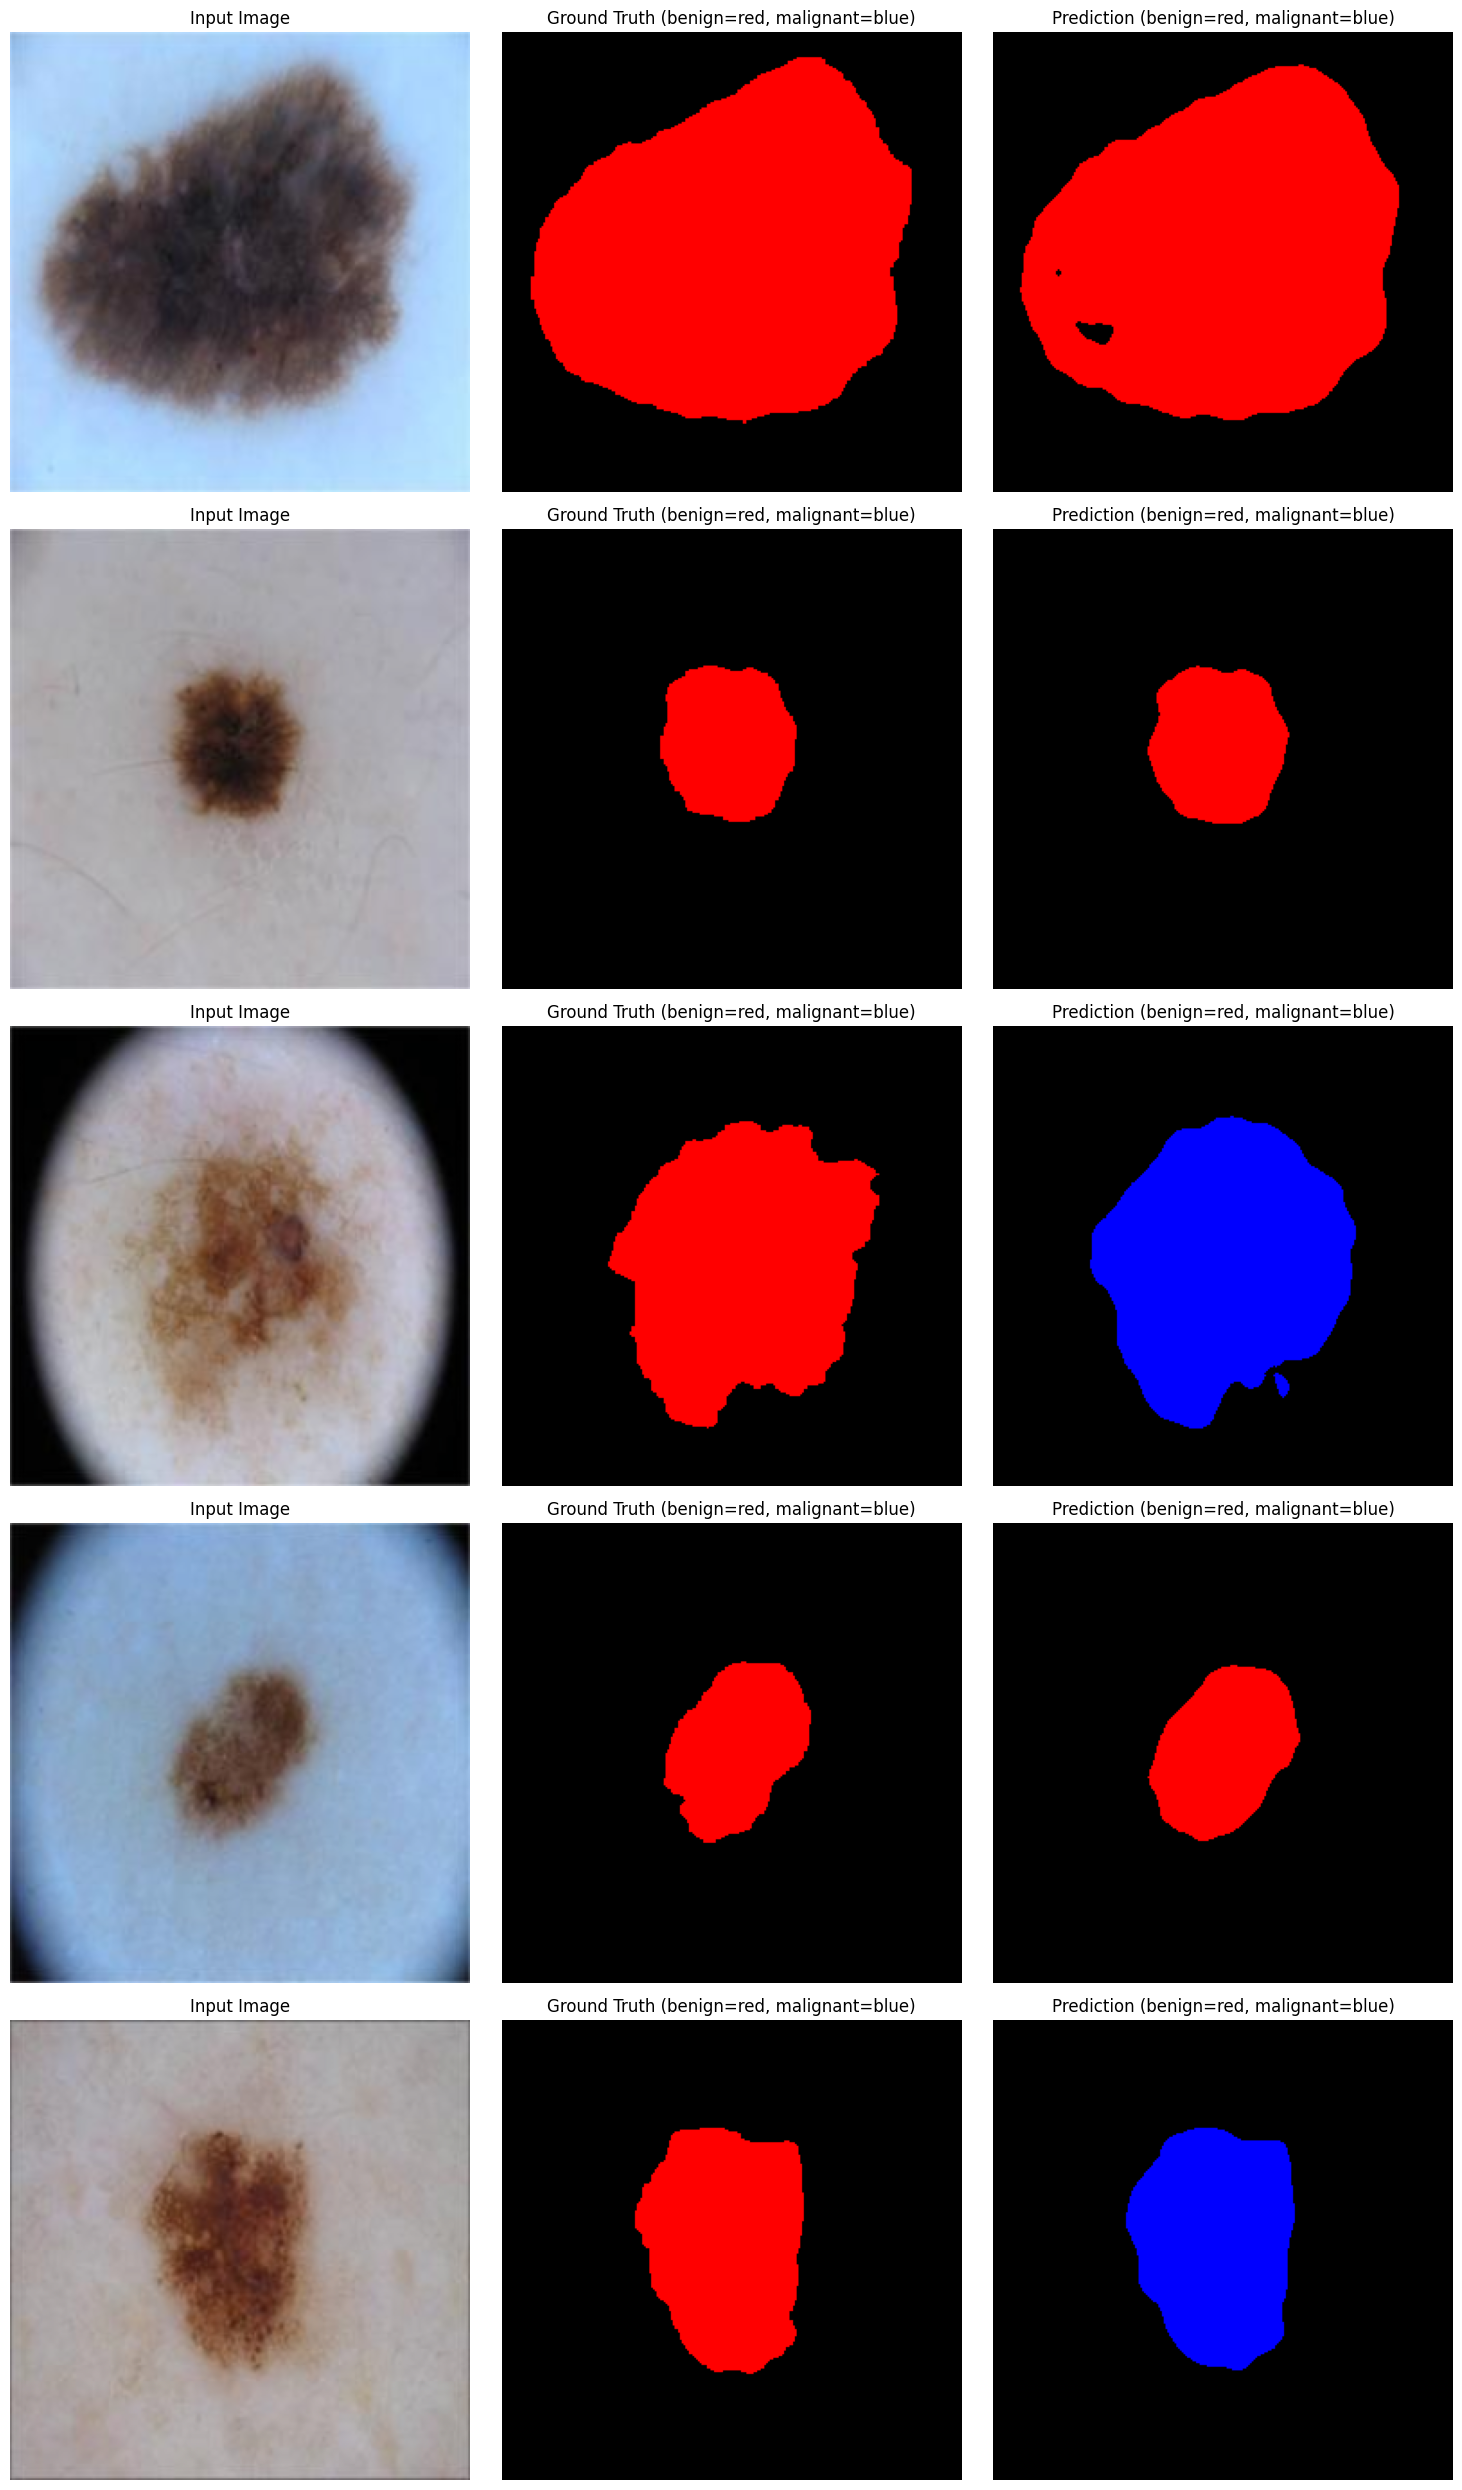


Multi-seed training complete:
  seed 22: dice=0.5980  iou=0.4633  → /home/ahsan/test-project/ISIC-2019/ISIC_Multiclass_Seg/size_shortcuts/checkpoints/multiseed/UNet_ISIC_multiclass_seed22_epoch60.pth
  seed 42: dice=0.5650  iou=0.4316  → /home/ahsan/test-project/ISIC-2019/ISIC_Multiclass_Seg/size_shortcuts/checkpoints/multiseed/UNet_ISIC_multiclass_seed42_epoch60.pth
  seed 123: dice=0.5605  iou=0.4323  → /home/ahsan/test-project/ISIC-2019/ISIC_Multiclass_Seg/size_shortcuts/checkpoints/multiseed/UNet_ISIC_multiclass_seed123_epoch60.pth


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import albumentations as A
import torch.nn.functional as F
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
import numpy as np
import torchvision.transforms as T
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
from torch.utils.data import DataLoader
from collections import defaultdict

# Config
import random

BATCH_SIZE  = 32
NUM_CLASSES = 3        # 0=background, 1=benign, 2=malignant
CLASS_NAMES = ["background", "benign", "malignant"]
EPOCHS      = 60      # use 2 for quick debug
LR_INITIAL  = 1e-4
DEVICE      = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
IMG_SIZE    = 256
SEEDS       = [22, 42, 123]
CHECKPOINT_DIR = "/home/ahsan/test-project/ISIC-2019/ISIC_Multiclass_Seg/checkpoints/multiseed"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Transforms 
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# Dataset
class ISIC_Dataset(Dataset):
    def __init__(self, csv_path, image_dir, mask_dir, transform=None, img_size=256):
        self.image_dir = image_dir
        self.mask_dir  = mask_dir
        self.transform = transform
        self.img_size  = img_size

        df             = pd.read_csv(csv_path)
        df.columns     = df.columns.str.strip()

        # Strip extension from isic_id if present
        df["isic_id"]  = df["isic_id"].str.strip()

        self.ids       = df["isic_id"].tolist()

        # <<< FIX: read benign_malignant label to assign class 1 or 2
        self.benign_malignant = df["benign_malignant"].astype(int).tolist()

        print(f"Loaded {len(self.ids)} samples from {csv_path}")
        print(f"  Benign    (class 1): {df['benign_malignant'].eq(0).sum()}")
        print(f"  Malignant (class 2): {df['benign_malignant'].eq(1).sum()}")

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        isic_id = self.ids[idx]
        bm      = self.benign_malignant[idx]   # 0=benign → class 1
                                               # 1=malignant → class 2

        img_path  = os.path.join(self.image_dir, isic_id)
        mask_name = isic_id.replace(".jpg", "_segmentation.png")
        mask_path = os.path.join(self.mask_dir, mask_name)

        image = np.array(Image.open(img_path).convert("RGB"))
        mask  = np.array(Image.open(mask_path).convert("L"))

        # <<< FIX: build 3-class mask using benign_malignant label
        # 0=background, 1=benign, 2=malignant
        binary_mask = (mask > 127).astype(np.int64)
        class_label = bm + 1                        # 0→1, 1→2
        seg_mask    = binary_mask * class_label      # bg stays 0

        if self.transform:
            aug   = self.transform(image=image, mask=seg_mask)
            image = aug["image"]                     # [3, H, W]
            mask  = aug["mask"]                      # [H, W]
        else:
            mask = torch.as_tensor(seg_mask)

        if not isinstance(mask, torch.Tensor):
            mask = torch.as_tensor(mask)
        if mask.ndim == 3:
            mask = mask.squeeze(0)
        mask = mask.long()                           # must be long for multiclass

        return image, mask


# Verify masks before training 
def verify_dataset_classes(dataset, name="Dataset", n_batches=10):
    """Confirm class 0, 1, 2 all appear in masks."""
    loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=2)
    all_classes = set()

    for i, (images, masks) in enumerate(loader):
        for v in masks.unique().tolist():
            all_classes.add(int(v))
        if i >= n_batches:
            break

    print(f"\n[{name}] Unique class values in masks: {sorted(all_classes)}")
    if 2 not in all_classes:
        print(f"  *** WARNING: class 2 (malignant) NOT found — "
              f"check benign_malignant column in CSV ***")
    else:
        print(f"  OK — all 3 classes present (0=bg, 1=benign, 2=malignant)")

ISIC_train_dataset = ISIC_Dataset(
    image_dir = '/home/ahsan/test-project/ISIC-2019/ISIC_Dataset/isic_imagefolder/isic_shortcut/train_shortcut_30%_without_patch/images',
    mask_dir = '/home/ahsan/test-project/ISIC-2019/ISIC_Dataset/isic_imagefolder/isic_shortcut/train_shortcut_30%_without_patch/masks',
    csv_path = '/home/ahsan/test-project/ISIC-2019/ISIC_Metadata/train_metadata_without_patches_size_shortcut.csv',
    transform = train_transform,
    img_size  = IMG_SIZE,
)
ISIC_test_dataset = ISIC_Dataset(
    csv_path  = '/home/ahsan/test-project/fss/ISIC/ISIC_metadata/test_metadata_sample_data.csv',
    image_dir = '/home/ahsan/test-project/fss/ISIC/ISIC_224_Dataset/isic_test',
    mask_dir  = '/home/ahsan/test-project/ISIC-2019/ISIC_Dataset/isic_masks/test_masks',
    transform = val_transform,
    img_size  = IMG_SIZE,
)

# Verify both datasets have all 3 classes 
verify_dataset_classes(ISIC_train_dataset, name="Train")
verify_dataset_classes(ISIC_test_dataset,  name="Test")

train_loader = DataLoader(ISIC_train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=4, pin_memory=True)
test_loader  = DataLoader(ISIC_test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=4, pin_memory=True)
val_loader   = test_loader

criterion = smp.losses.DiceLoss(mode="multiclass", from_logits=True)

# Metrics
def compute_metrics(outputs, masks, num_classes, smooth=1e-6):
    preds        = outputs.argmax(dim=1)
    acc          = (preds == masks).float().mean().item()
    preds_flat   = preds.view(-1)
    masks_flat   = masks.view(-1)
    preds_one_hot = F.one_hot(preds_flat, num_classes=num_classes).float()
    masks_one_hot = F.one_hot(masks_flat, num_classes=num_classes).float()
    inter         = (preds_one_hot * masks_one_hot).sum(dim=0)
    total_preds   = preds_one_hot.sum(dim=0)
    total_masks   = masks_one_hot.sum(dim=0)
    union         = total_preds + total_masks - inter

    # Skip background (index 0)
    inter       = inter[1:]
    union       = union[1:]
    total_preds = total_preds[1:]
    total_masks = total_masks[1:]

    class_present = (total_masks > 0)
    if class_present.sum() == 0:
        return {"acc": acc, "dice": 0.0, "iou": 0.0}

    dice_per_class = (2 * inter + smooth) / (total_preds + total_masks + smooth)
    iou_per_class  = (inter + smooth) / (union + smooth)

    return {
        "acc"  : acc,
        "dice" : dice_per_class[class_present].mean().item(),
        "iou"  : iou_per_class[class_present].mean().item(),
    }

# Training Loop (one run per seed)
all_seed_runs = []

for seed in SEEDS:
    set_seed(seed)
    print(f"\n{'='*70}\nTraining seed {seed}\n{'='*70}")

    model = smp.Unet(
        encoder_name    = "resnet34",
        encoder_weights = "imagenet",
        in_channels     = 3,
        classes         = NUM_CLASSES,
    ).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR_INITIAL)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                      patience=5, factor=0.5)

    train_losses, val_losses         = [], []
    train_dices,  val_dices          = [], []
    train_accuracies, val_accuracies = [], []
    training_iou, validating_iou     = [], []

    for epoch in range(EPOCHS):
        model.train()
        train_loss = train_dice = train_acc = train_iou = 0.0

        for images, masks in train_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            m = compute_metrics(outputs, masks, NUM_CLASSES)
            train_acc  += m["acc"]
            train_dice += m["dice"]
            train_iou  += m["iou"]

        n = len(train_loader)
        avg_train_loss = train_loss / n
        avg_train_dice = train_dice / n
        avg_train_acc  = train_acc  / n
        avg_train_iou  = train_iou  / n

        model.eval()
        val_loss = val_dice = val_acc = val_iou = 0.0

        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(DEVICE), masks.to(DEVICE)
                outputs = model(images)
                loss    = criterion(outputs, masks)

                val_loss += loss.item()
                m = compute_metrics(outputs, masks, NUM_CLASSES)
                val_acc  += m["acc"]
                val_dice += m["dice"]
                val_iou  += m["iou"]

        n = len(val_loader)
        avg_val_loss = val_loss / n
        avg_val_dice = val_dice / n
        avg_val_acc  = val_acc  / n
        avg_val_iou  = val_iou  / n

        train_losses.append(avg_train_loss); val_losses.append(avg_val_loss)
        train_dices.append(avg_train_dice);  val_dices.append(avg_val_dice)
        train_accuracies.append(avg_train_acc); val_accuracies.append(avg_val_acc)
        training_iou.append(avg_train_iou);  validating_iou.append(avg_val_iou)

        scheduler.step(avg_val_loss)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{EPOCHS}:")
            print(f"  Train Loss:{avg_train_loss:.4f}  Dice:{avg_train_dice:.4f}  "
                  f"Acc:{avg_train_acc:.4f}  IoU:{avg_train_iou:.4f}")
            print(f"  Val   Loss:{avg_val_loss:.4f}  Dice:{avg_val_dice:.4f}  "
                  f"Acc:{avg_val_acc:.4f}  IoU:{avg_val_iou:.4f}")

    ckpt_path = f"{CHECKPOINT_DIR}/UNet_ISIC_multiclass_seed{seed}_epoch{EPOCHS}.pth"
    torch.save(model.state_dict(), ckpt_path)
    print(f"Saved checkpoint → {ckpt_path}")
    all_seed_runs.append({
        "seed": seed,
        "checkpoint": ckpt_path,
        "final_val_dice": val_dices[-1],
        "final_val_iou": validating_iou[-1],
    })

# Plot last seed's curves
seed = all_seed_runs[-1]["seed"]
print(f"\nPlotting curves for last seed ({seed})")
# Plotting 
plt.figure(figsize=(15, 5))
plt.subplot(1,3,1)
plt.plot(train_losses, label='Train'); plt.plot(val_losses, label='Val')
plt.title('Loss'); plt.xlabel('Epoch'); plt.legend()
plt.subplot(1,3,2)
plt.plot(train_dices, label='Train'); plt.plot(val_dices, label='Val')
plt.title('Dice'); plt.xlabel('Epoch'); plt.legend()
plt.subplot(1,3,3)
plt.plot(train_accuracies, label='Train'); plt.plot(val_accuracies, label='Val')
plt.title('Accuracy'); plt.xlabel('Epoch'); plt.legend()
plt.tight_layout(); plt.show()

# Visualization
def mask_to_rgb(mask_2d):
    if isinstance(mask_2d, torch.Tensor):
        mask_2d = mask_2d.cpu().numpy()
    mask_2d = np.squeeze(mask_2d)
    h, w    = mask_2d.shape
    rgb     = np.zeros((h, w, 3), dtype=np.uint8)
    rgb[mask_2d == 0] = [0,   0,   0  ]   # background → black
    rgb[mask_2d == 1] = [255, 0,   0  ]   # benign     → red
    rgb[mask_2d == 2] = [0,   0, 255  ]   # malignant  → blue
    return rgb

model.eval()
num_examples  = 5
val_iter      = iter(val_loader)
fig, axes     = plt.subplots(num_examples, 3, figsize=(15, 5 * num_examples))
example_count = 0
test_dice     = 0.0

with torch.no_grad():
    while example_count < num_examples:
        images, masks = next(val_iter)
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        outputs       = model(images)
        pred_labels   = outputs.argmax(dim=1)

        m = compute_metrics(outputs, masks, NUM_CLASSES)
        test_dice += m["dice"]

        for i in range(images.size(0)):
            mask_np = masks[i].cpu().numpy()
            if mask_np.max() > 0:
                img      = np.transpose(images[i].cpu().numpy(), (1, 2, 0))
                mean     = np.array([0.485, 0.456, 0.406])
                std      = np.array([0.229, 0.224, 0.225])
                img      = (img * std + mean).clip(0, 1)
                pred_np  = pred_labels[i].cpu().numpy()

                gt_class   = CLASS_NAMES[int(mask_np.max())]
                pred_class = CLASS_NAMES[int(pred_np.max())] if pred_np.max() > 0 else "background"
                print(f"Sample {example_count+1}: GT={gt_class}  Pred={pred_class}")

                axes[example_count, 0].imshow(img)
                axes[example_count, 0].set_title("Input Image")
                axes[example_count, 0].axis("off")

                axes[example_count, 1].imshow(mask_to_rgb(mask_np))
                axes[example_count, 1].set_title("Ground Truth (benign=red, malignant=blue)")
                axes[example_count, 1].axis("off")

                axes[example_count, 2].imshow(mask_to_rgb(pred_np))
                axes[example_count, 2].set_title("Prediction (benign=red, malignant=blue)")
                axes[example_count, 2].axis("off")

                example_count += 1
                if example_count >= num_examples:
                    break

print(f"Avg Test Dice: {test_dice / num_examples:.4f}")
plt.tight_layout()
plt.show()

print("\nMulti-seed training complete:")
for run in all_seed_runs:
    print(f"  seed {run['seed']}: dice={run['final_val_dice']:.4f}  iou={run['final_val_iou']:.4f}  → {run['checkpoint']}")